In [28]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
path = r"H:\3A2 Python\3 Etapa\PGT\PandasIn3\CD2022_Populacao_2010_Compatibilizada_20231222 (1).xlsx"

df_raw = pd.read_excel(path, sheet_name="Municípios", header=2)

df_raw.head()

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0


In [30]:
# Seleciona e renomeia as colunas de interesse
df = df_raw[[
    "UF",
    "COD. UF",
    "COD. MUNIC",
    "NOME DO MUNICÍPIO",
    "População 2010 (Alterações de Limites até 2022)1",
    "População Censo 2022",
]].copy()

df.columns = [
    "UF",
    "COD_UF",
    "COD_MUNIC",
    "MUNICIPIO",
    "POP_2010",
    "POP_2022",
]

# Remove linhas de rodapé (notas/fonte) que não possuem código de UF
df = df.dropna(subset=["COD_UF"])

df["COD_UF"] = df["COD_UF"].astype(int)
df["COD_MUNIC"] = df["COD_MUNIC"].astype(int)
df["POP_2010"] = df["POP_2010"].astype(int)
df["POP_2022"] = df["POP_2022"].astype(int)

col_2010 = "POP_2010"
col_2022 = "POP_2022"

print(df.shape)
df.head()


(5570, 6)


,UF,COD_UF,COD_MUNIC,MUNICIPIO,POP_2010,POP_2022
0,RO,11,15,Alta Floresta D'Oeste,24392,21494
1,RO,11,23,Ariquemes,90353,96833
2,RO,11,31,Cabixi,6313,5351
3,RO,11,49,Cacoal,78574,86887
4,RO,11,56,Cerejeiras,17029,15890


In [31]:
pop_estado = (
    df.groupby(["COD_UF", "UF"], as_index=False)
      .agg(
          populacao_2010=(col_2010, "sum"),
          populacao_2022=(col_2022, "sum"),
      )
)

pop_estado.head()


,COD_UF,UF,populacao_2010,populacao_2022
0,11,RO,1562409,1581196
1,12,AC,733559,830018
2,13,AM,3483985,3941613
3,14,RR,450479,636707
4,15,PA,7581051,8120131


In [32]:
pop_estado["crescimento_absoluto"] = pop_estado["populacao_2022"] - pop_estado["populacao_2010"]
pop_estado["crescimento_percentual"] = (
    pop_estado["crescimento_absoluto"] / pop_estado["populacao_2010"] * 100
).round(2)

pop_estado = pop_estado.sort_values("crescimento_absoluto", ascending=False).reset_index(drop=True)

pop_estado

,COD_UF,UF,populacao_2010,populacao_2022,crescimento_absoluto,crescimento_percentual
0,35,SP,41262199,44411238,3149039,7.63
1,42,SC,6248436,7610361,1361925,21.80
2,52,GO,6001789,7056495,1054706,17.57
3,41,PR,10444526,11444380,999854,9.57
4,31,MG,19597330,20539989,942659,4.81
5,51,MT,3035122,3658649,623527,20.54
6,15,PA,7581051,8120131,539080,7.11
7,13,AM,3483985,3941613,457628,13.14
8,23,CE,8451644,8794957,343313,4.06
9,32,ES,3514952,3833712,318760,9.07


In [33]:
pop_estado.to_csv(r"pop_estado.csv", sep=";", index=False, encoding="utf-8-sig")
print("Arquivo salvo: pop_estado.csv")


Arquivo salvo: pop_estado.csv


In [34]:
pop_municipio = (
    df.groupby(["COD_UF", "UF", "COD_MUNIC", "MUNICIPIO"], as_index=False)
      .agg(
          populacao_2010=(col_2010, "sum"),
          populacao_2022=(col_2022, "sum"),
      )
)

pop_municipio.head()

,COD_UF,UF,COD_MUNIC,MUNICIPIO,populacao_2010,populacao_2022
0,11,RO,15,Alta Floresta D'Oeste,24392,21494
1,11,RO,23,Ariquemes,90353,96833
2,11,RO,31,Cabixi,6313,5351
3,11,RO,49,Cacoal,78574,86887
4,11,RO,56,Cerejeiras,17029,15890


In [35]:
pop_municipio["crescimento_absoluto"] = pop_municipio["populacao_2022"] - pop_municipio["populacao_2010"]
pop_municipio["crescimento_percentual"] = (
    pop_municipio["crescimento_absoluto"] / pop_municipio["populacao_2010"] * 100
).round(2)

pop_municipio = pop_municipio.sort_values("crescimento_absoluto", ascending=False).reset_index(drop=True)

pop_municipio.head(20)


,COD_UF,UF,COD_MUNIC,MUNICIPIO,populacao_2010,populacao_2022,crescimento_absoluto,crescimento_percentual
0,13,AM,2603,Manaus,1802014,2063689,261675,14.52
1,53,DF,108,Brasília,2572159,2817381,245222,9.53
2,35,SP,50308,São Paulo,11253503,11451999,198496,1.76
3,35,SP,52205,Sorocaba,586816,723682,136866,23.32
4,52,GO,8707,Goiânia,1301912,1437366,135454,10.40
5,14,RR,100,Boa Vista,284313,413486,129173,45.43
6,42,SC,5407,Florianópolis,421240,537211,115971,27.53
7,15,PA,5536,Parauapebas,153908,267836,113928,74.02
8,50,MS,2704,Campo Grande,786774,898100,111326,14.15
9,25,PB,7507,João Pessoa,723515,833932,110417,15.26


In [36]:
pop_municipio.to_csv(r"pop_municipio.csv", sep=";", index=False, encoding="utf-8-sig")
print("Arquivo salvo: pop_municipio.csv")

Arquivo salvo: pop_municipio.csv


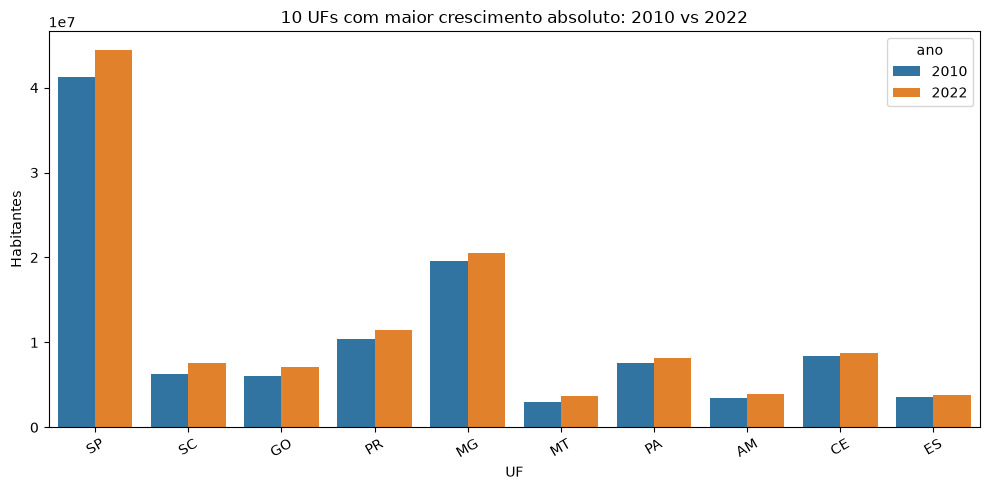

In [37]:
top = pop_estado.head(10).melt(
    id_vars="UF",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)
top["ano"] = top["ano"].map({"populacao_2010": "2010", "populacao_2022": "2022"})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_xlabel("UF")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("grafico_top10_estados_2010_2022.png", dpi=150)
plt.show()


C:\Users\22401768\AppData\Local\Temp\ipykernel_11104\2442465512.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


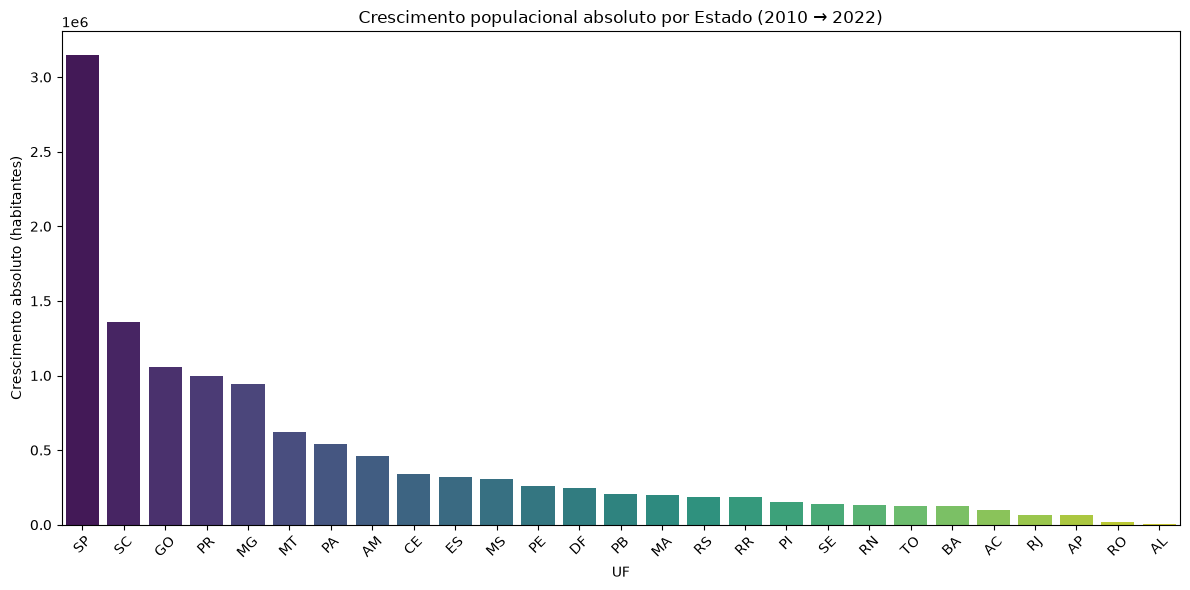

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
ordem = pop_estado.sort_values("crescimento_absoluto", ascending=False)["UF"]
sns.barplot(
    data=pop_estado,
    x="UF",
    y="crescimento_absoluto",
    order=ordem,
    palette="viridis",
    ax=ax,
)
ax.set_title("Crescimento populacional absoluto por Estado (2010 → 2022)")
ax.set_xlabel("UF")
ax.set_ylabel("Crescimento absoluto (habitantes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grafico_crescimento_absoluto_estados.png", dpi=150)
plt.show()


C:\Users\22401768\AppData\Local\Temp\ipykernel_11104\566032937.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


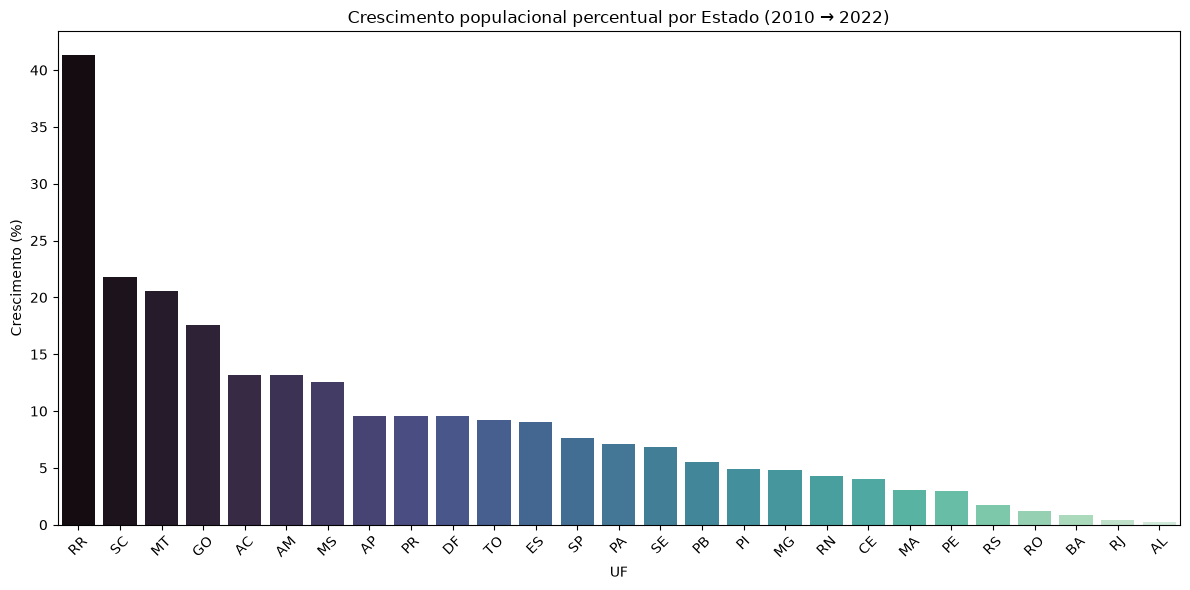

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
ordem_pct = pop_estado.sort_values("crescimento_percentual", ascending=False)["UF"]
sns.barplot(
    data=pop_estado,
    x="UF",
    y="crescimento_percentual",
    order=ordem_pct,
    palette="mako",
    ax=ax,
)
ax.set_title("Crescimento populacional percentual por Estado (2010 → 2022)")
ax.set_xlabel("UF")
ax.set_ylabel("Crescimento (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("grafico_crescimento_percentual_estados.png", dpi=150)
plt.show()


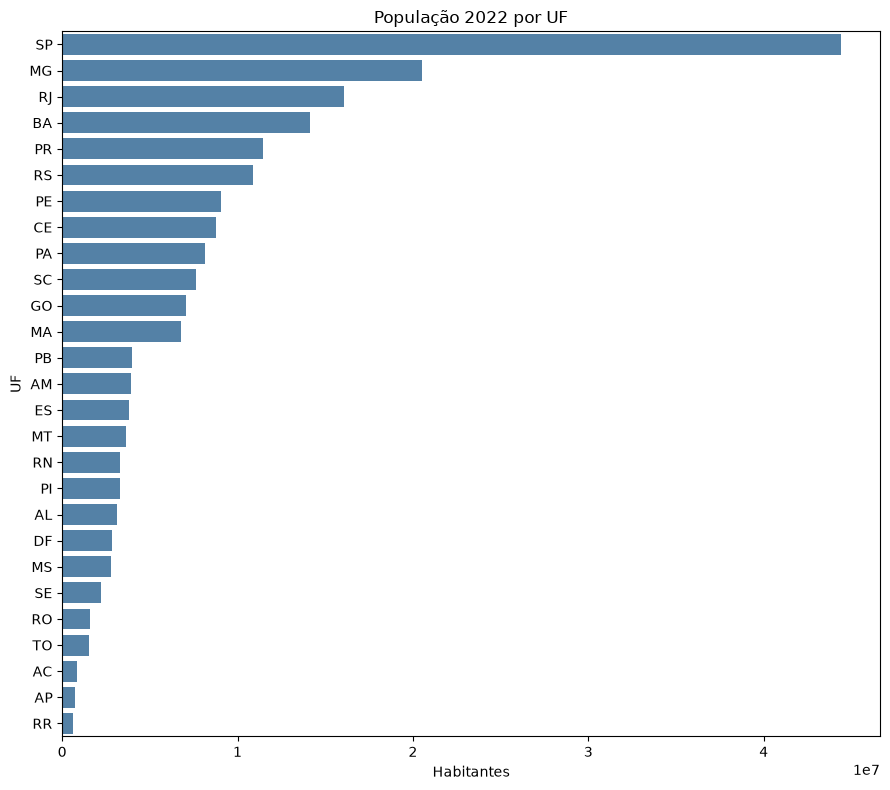

In [40]:
fig, ax = plt.subplots(figsize=(9, 8))
ordem = pop_estado.sort_values("populacao_2022", ascending=False)
sns.barplot(data=ordem, y="UF", x="populacao_2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()

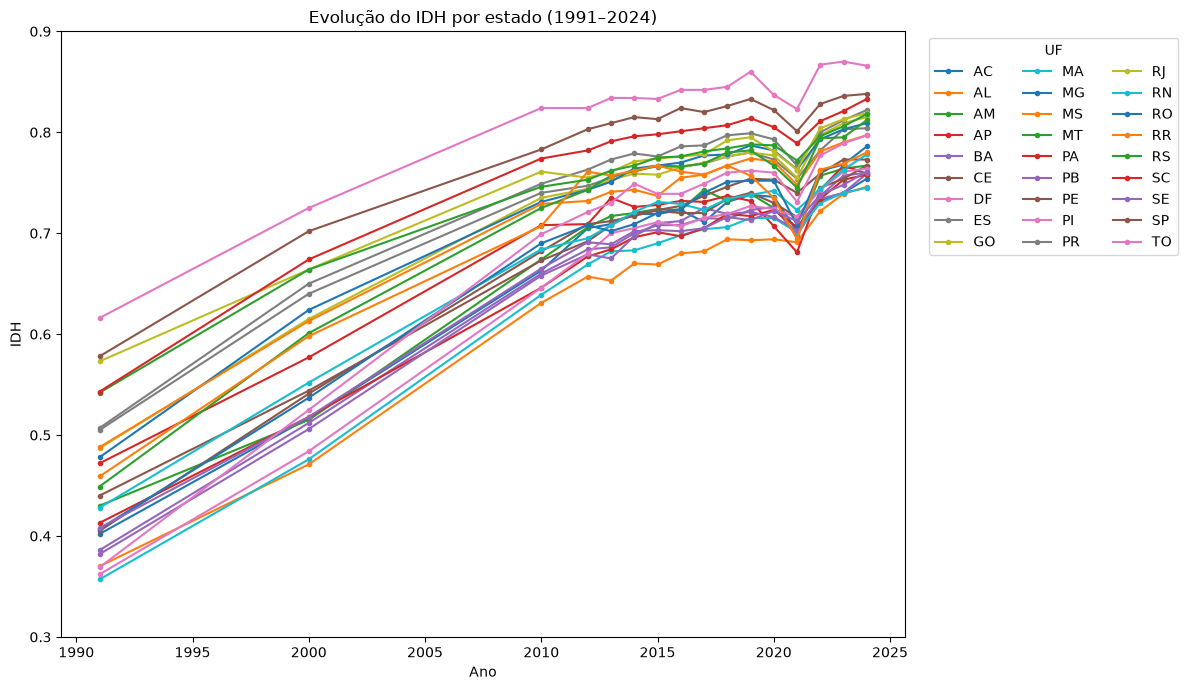

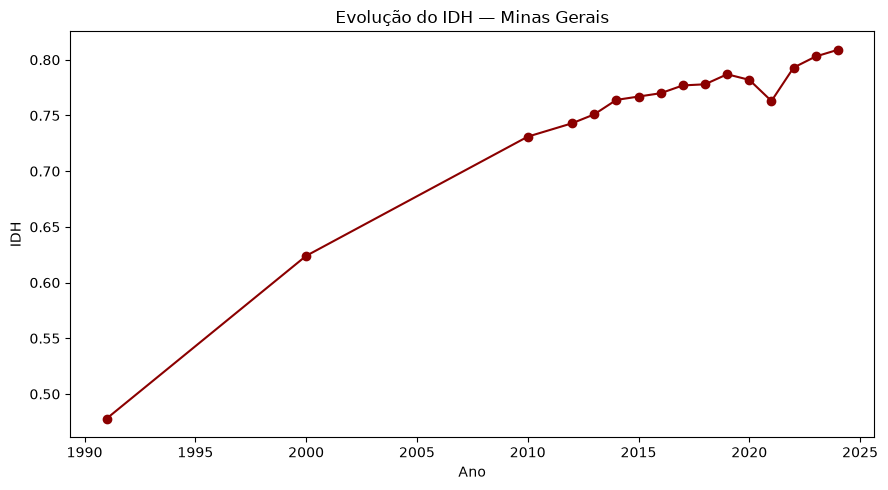

In [41]:
df = pd.read_csv("Tabela4.csv", sep=";", decimal=",", encoding="latin1", skiprows=1)

df = df.dropna(axis=1, how="all")

anos = [c for c in df.columns if str(c).isdigit()]
variaveis = [c for c in df.columns if c not in anos]

df_longo = df.melt(
    id_vars=variaveis,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)

fig, ax = plt.subplots(figsize=(12, 7))
for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()

mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mg["Ano"], mg["IDH"], marker="o", color="darkred")
ax.set_title("Evolução do IDH — Minas Gerais")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
plt.tight_layout()
plt.show()